In [1]:
import pandas as pd

df = pd.read_csv('cycle_data_full.csv')

# 1. Shape
print("Rows and Columns:", df.shape)

# 2. Data types
print("\nData Types:")
print(df.dtypes)

# 3. Missing values
print("\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# 4. First few rows
print("\nFirst 3 rows:")
print(df.head(3))

Rows and Columns: (7200, 34)

Data Types:
user_id                          int64
cycle_number                     int64
cycle_date                      object
month_number                     int64
season                          object
age                              int64
age_group                       object
bmi                            float64
bmi_category                    object
condition                       object
contraceptive                   object
personal_base_gap                int64
cycle_length                     int64
stress_level                     int64
sleep_quality                    int64
activity_level                  object
pain_level                       int64
mood_score                       int64
hydration_level                  int64
travel_disruption                 bool
recent_illness                    bool
flow_intensity                  object
prev_cycle_had_spotting         object
prev_cycle_gap                 float64
two_months_ago_spottin

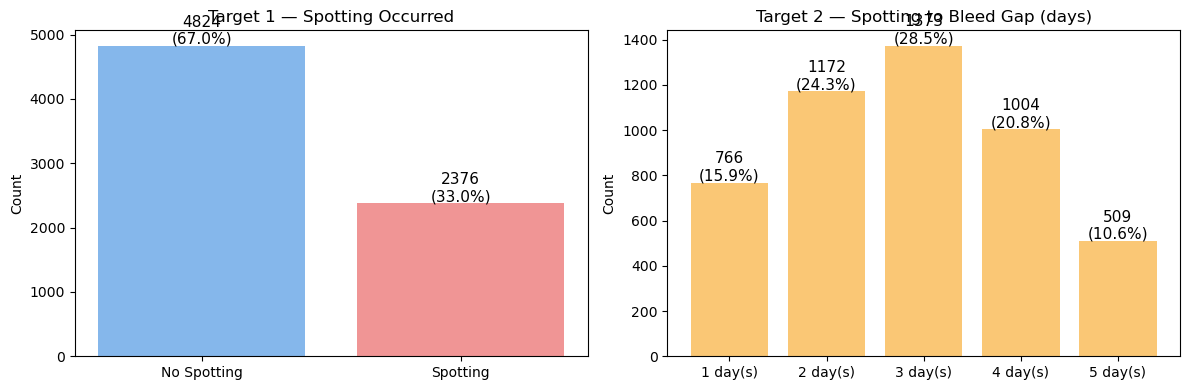

Target 1 — Spotting Occurred:
spotting_occurred
True     4824
False    2376
Name: count, dtype: int64

Spotting rate: 67.0%

Target 2 — Gap Distribution:
spotting_to_bleed_gap
1.0     766
2.0    1172
3.0    1373
4.0    1004
5.0     509
Name: count, dtype: int64


In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target 1 — spotting_occurred distribution
spotting_counts = df['spotting_occurred'].value_counts()
axes[0].bar(['No Spotting', 'Spotting'], spotting_counts.values, color=['#85B7EB', '#F09595'])
axes[0].set_title('Target 1 — Spotting Occurred')
axes[0].set_ylabel('Count')
for i, v in enumerate(spotting_counts.values):
    axes[0].text(i, v + 30, f'{v}\n({round(v/len(df)*100, 1)}%)', ha='center', fontsize=11)

# Target 2 — gap distribution (only spotting months)
gap_data = df['spotting_to_bleed_gap'].dropna()
gap_counts = gap_data.value_counts().sort_index()
axes[1].bar([f'{int(d)} day(s)' for d in gap_counts.index], gap_counts.values, color='#FAC775')
axes[1].set_title('Target 2 — Spotting to Bleed Gap (days)')
axes[1].set_ylabel('Count')
for i, v in enumerate(gap_counts.values):
    axes[1].text(i, v + 10, f'{v}\n({round(v/len(gap_data)*100, 1)}%)', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

# Print summary
print("Target 1 — Spotting Occurred:")
print(spotting_counts)
print(f"\nSpotting rate: {round(spotting_counts[True]/len(df)*100, 1)}%")
print("\nTarget 2 — Gap Distribution:")
print(gap_counts)

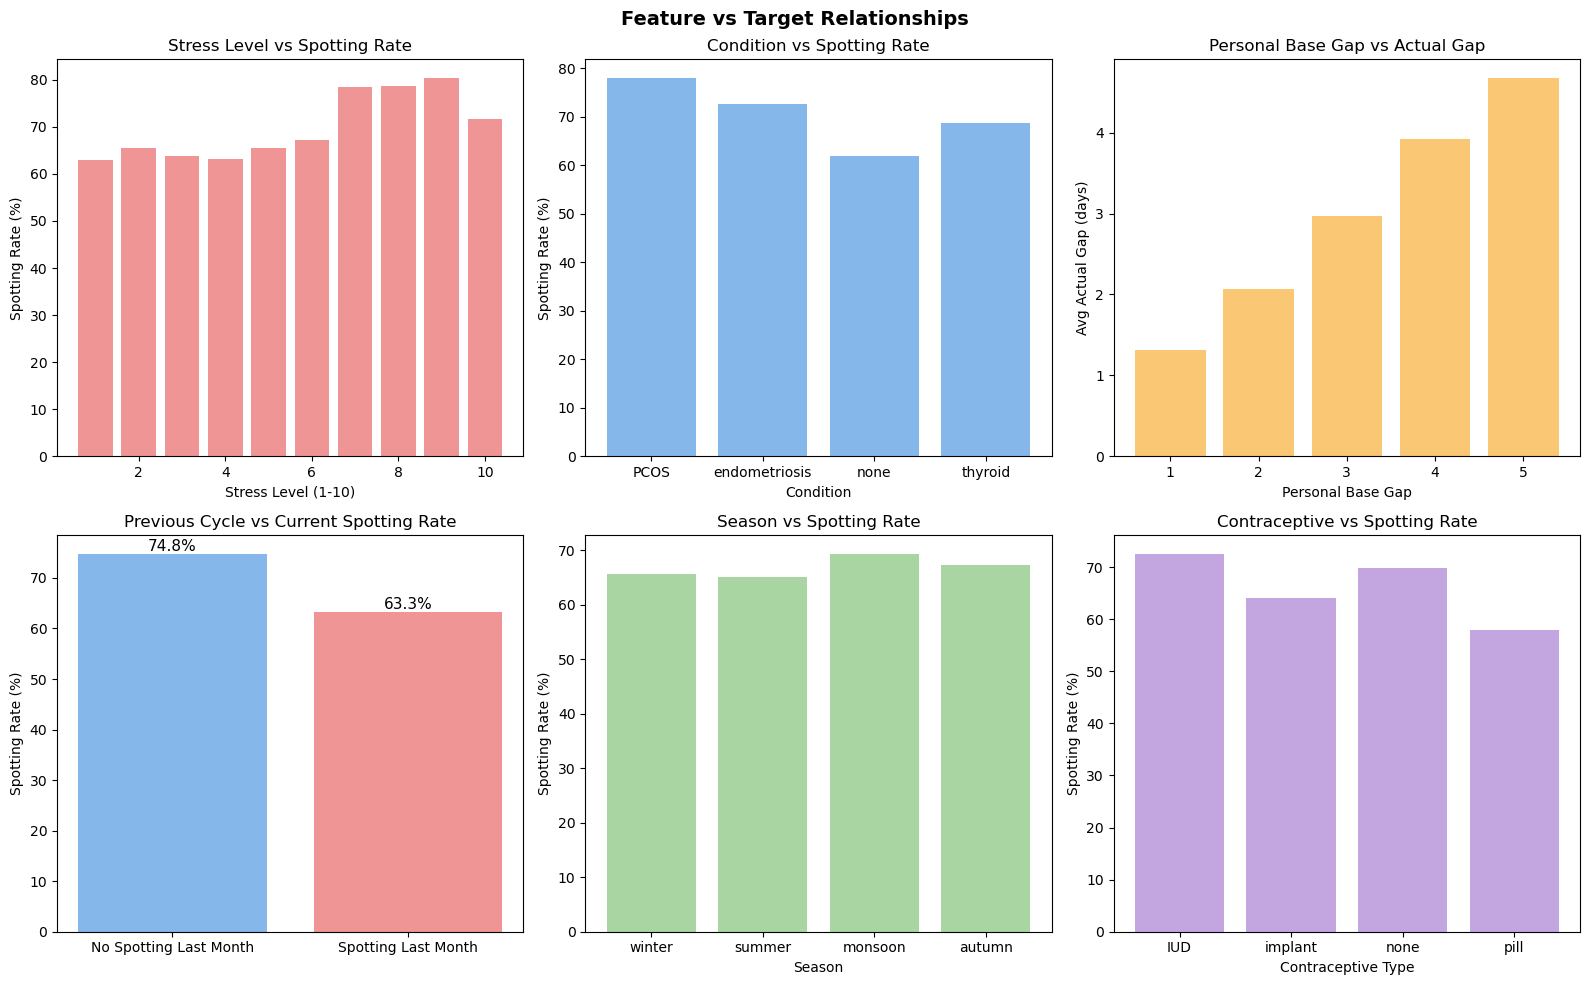

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Feature vs Target Relationships', fontsize=14, fontweight='bold')

# 1. Stress level vs Spotting occurred
stress_spot = df.groupby('stress_level')['spotting_occurred'].mean() * 100
axes[0,0].bar(stress_spot.index, stress_spot.values, color='#F09595')
axes[0,0].set_title('Stress Level vs Spotting Rate')
axes[0,0].set_xlabel('Stress Level (1-10)')
axes[0,0].set_ylabel('Spotting Rate (%)')

# 2. Condition vs Spotting rate
cond_spot = df.groupby('condition')['spotting_occurred'].mean() * 100
axes[0,1].bar(cond_spot.index, cond_spot.values, color='#85B7EB')
axes[0,1].set_title('Condition vs Spotting Rate')
axes[0,1].set_xlabel('Condition')
axes[0,1].set_ylabel('Spotting Rate (%)')

# 3. Personal base gap vs Actual gap
base_actual = df.dropna(subset=['spotting_to_bleed_gap']).groupby('personal_base_gap')['spotting_to_bleed_gap'].mean()
axes[0,2].bar(base_actual.index, base_actual.values, color='#FAC775')
axes[0,2].set_title('Personal Base Gap vs Actual Gap')
axes[0,2].set_xlabel('Personal Base Gap')
axes[0,2].set_ylabel('Avg Actual Gap (days)')

# 4. Previous cycle spotting vs Current spotting
prev_spot = df.dropna(subset=['prev_cycle_had_spotting']).groupby('prev_cycle_had_spotting')['spotting_occurred'].mean() * 100
axes[1,0].bar(['No Spotting Last Month', 'Spotting Last Month'], prev_spot.values, color=['#85B7EB', '#F09595'])
axes[1,0].set_title('Previous Cycle vs Current Spotting Rate')
axes[1,0].set_ylabel('Spotting Rate (%)')
for i, v in enumerate(prev_spot.values):
    axes[1,0].text(i, v + 0.5, f'{round(v,1)}%', ha='center', fontsize=11)

# 5. Season vs Spotting rate
season_order = ['winter', 'summer', 'monsoon', 'autumn']
season_spot = df.groupby('season')['spotting_occurred'].mean() * 100
season_spot = season_spot.reindex(season_order)
axes[1,1].bar(season_spot.index, season_spot.values, color='#A8D5A2')
axes[1,1].set_title('Season vs Spotting Rate')
axes[1,1].set_xlabel('Season')
axes[1,1].set_ylabel('Spotting Rate (%)')

# 6. Contraceptive vs Spotting rate
contra_spot = df.groupby('contraceptive')['spotting_occurred'].mean() * 100
axes[1,2].bar(contra_spot.index, contra_spot.values, color='#C3A6E0')
axes[1,2].set_title('Contraceptive vs Spotting Rate')
axes[1,2].set_xlabel('Contraceptive Type')
axes[1,2].set_ylabel('Spotting Rate (%)')

plt.tight_layout()
plt.show()

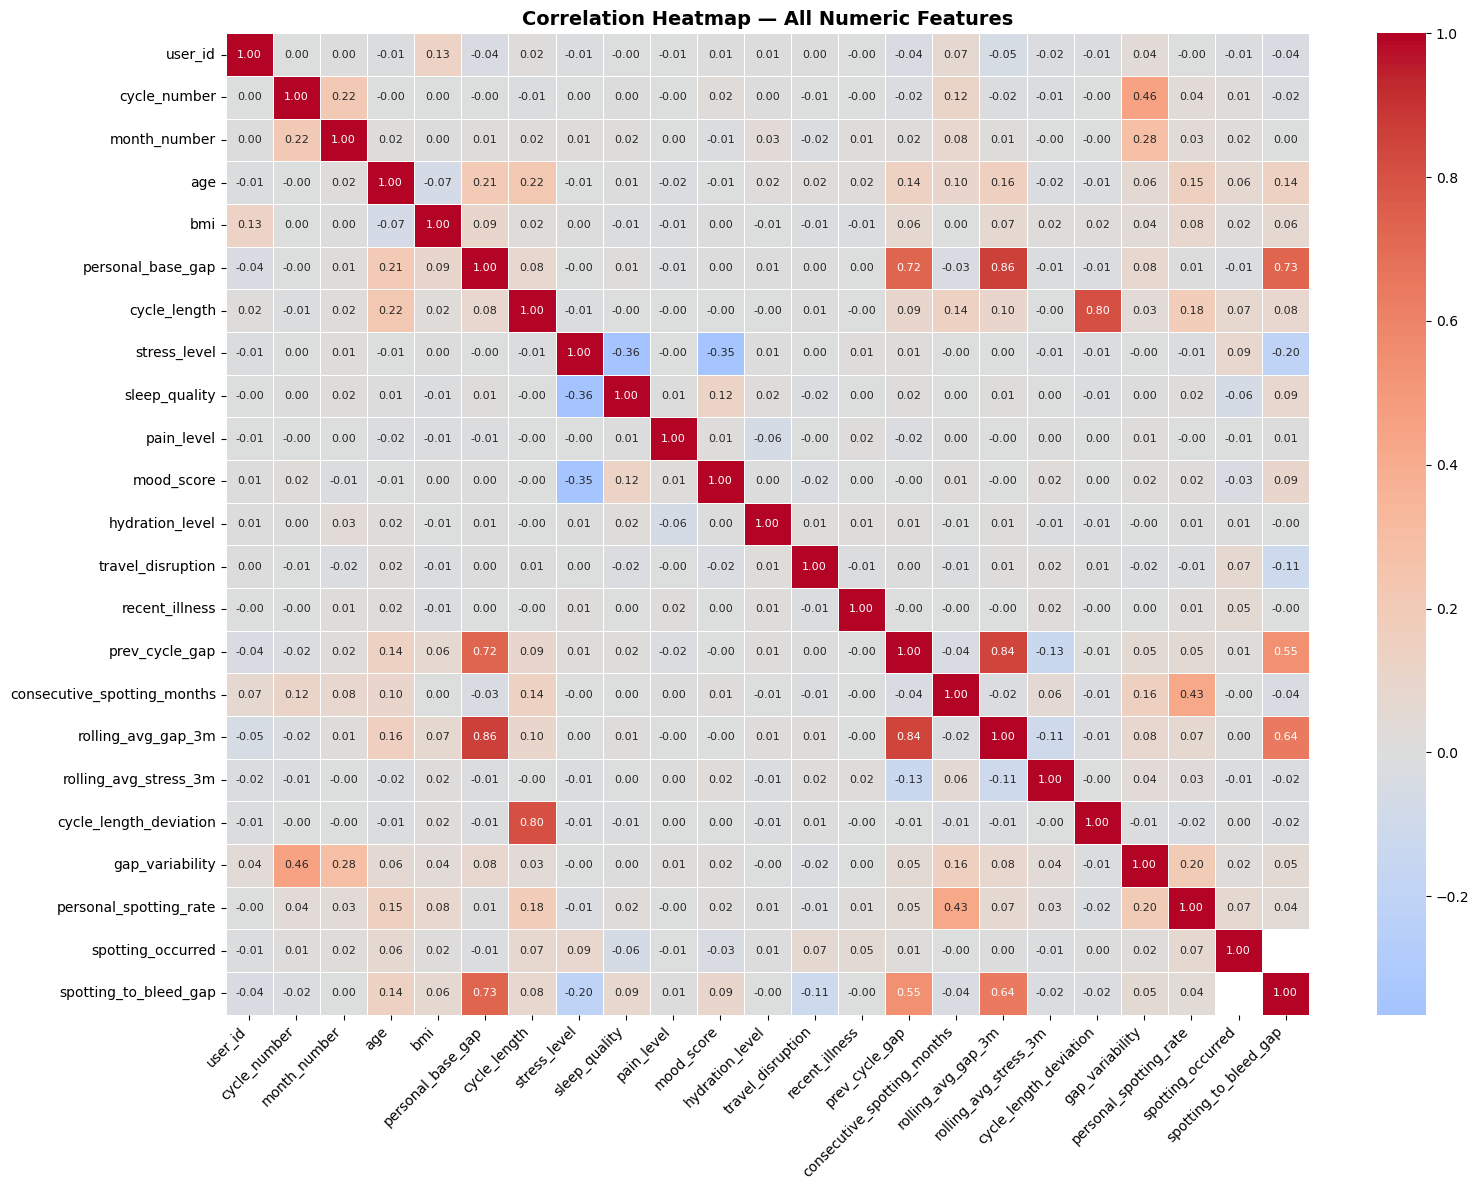

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64', 'bool']).columns.tolist()

# Compute correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plot
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Correlation Heatmap — All Numeric Features', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
pd.set_option('future.no_silent_downcasting', True)

# Make a copy so original data is preserved
df_clean = df.copy()

# Task 1 — Drop irrelevant columns
drop_cols = ['user_id', 'cycle_date', 'cycle_number']
df_clean = df_clean.drop(columns=drop_cols)

print("Shape after dropping irrelevant columns:", df_clean.shape)

# Task 2 — Handle missing values
df_clean['prev_cycle_had_spotting'] = df_clean['prev_cycle_had_spotting'].fillna(False).infer_objects(copy=False)
df_clean['two_months_ago_spotting'] = df_clean['two_months_ago_spotting'].fillna(False).infer_objects(copy=False)
df_clean['prev_cycle_gap'] = df_clean['prev_cycle_gap'].fillna(df_clean['personal_base_gap'])
df_clean['rolling_avg_gap_3m'] = df_clean['rolling_avg_gap_3m'].fillna(df_clean['personal_base_gap'])
df_clean['rolling_avg_stress_3m'] = df_clean['rolling_avg_stress_3m'].fillna(df_clean['stress_level'])
df_clean['personal_spotting_rate'] = df_clean['personal_spotting_rate'].fillna(0.5)

# Verify
missing = df_clean.isnull().sum()
missing = missing[missing > 0]
print("\nRemaining missing values:")
print(missing)

Shape after dropping irrelevant columns: (7200, 31)

Remaining missing values:
spotting_to_bleed_gap    2376
dtype: int64


In [6]:
# Task 3 — Drop redundant features identified from heatmap
# rolling_avg_gap_3m is highly correlated with personal_base_gap (0.86) 
# and prev_cycle_gap (0.84) — it adds no new information
drop_redundant = ['rolling_avg_gap_3m']
df_clean = df_clean.drop(columns=drop_redundant)

print("Shape after dropping redundant features:", df_clean.shape)
print("\nRemaining columns:")
for i, col in enumerate(df_clean.columns, 1):
    print(f"  {i:2}. {col}")

Shape after dropping redundant features: (7200, 30)

Remaining columns:
   1. month_number
   2. season
   3. age
   4. age_group
   5. bmi
   6. bmi_category
   7. condition
   8. contraceptive
   9. personal_base_gap
  10. cycle_length
  11. stress_level
  12. sleep_quality
  13. activity_level
  14. pain_level
  15. mood_score
  16. hydration_level
  17. travel_disruption
  18. recent_illness
  19. flow_intensity
  20. prev_cycle_had_spotting
  21. prev_cycle_gap
  22. two_months_ago_spotting
  23. consecutive_spotting_months
  24. rolling_avg_stress_3m
  25. stress_trend
  26. cycle_length_deviation
  27. gap_variability
  28. personal_spotting_rate
  29. spotting_occurred
  30. spotting_to_bleed_gap


In [7]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df_clean.copy()

# Boolean columns — convert to integers
bool_cols = ['travel_disruption', 'recent_illness', 
             'prev_cycle_had_spotting', 'two_months_ago_spotting',
             'spotting_occurred']
for col in bool_cols:
    df_encoded[col] = df_encoded[col].astype(int)

# Label encoding — ordered categories
label_maps = {
    'activity_level': {'low': 0, 'moderate': 1, 'high': 2},
    'stress_trend': {'decreasing': 0, 'stable': 1, 'increasing': 2},
    'bmi_category': {'underweight': 0, 'normal': 1, 'overweight': 2, 'obese': 3},
    'age_group': {'teen': 0, 'early_adult': 1, 'adult': 2, 'late_adult': 3},
    'flow_intensity': {'light': 0, 'medium': 1, 'heavy': 2}
}
for col, mapping in label_maps.items():
    df_encoded[col] = df_encoded[col].map(mapping)

# One hot encoding — unordered categories
ohe_cols = ['season', 'condition', 'contraceptive']
df_encoded = pd.get_dummies(df_encoded, columns=ohe_cols, drop_first=False)

print("Shape after encoding:", df_encoded.shape)
print("\nNew columns added by one hot encoding:")
new_cols = [c for c in df_encoded.columns if any(c.startswith(p+'_') for p in ohe_cols)]
print(new_cols)
print("\nData types sample:")
print(df_encoded.dtypes.value_counts())
# Convert remaining bool columns to int
bool_remaining = df_encoded.select_dtypes(include='bool').columns.tolist()
print("Bool columns to convert:", bool_remaining)
df_encoded[bool_remaining] = df_encoded[bool_remaining].astype(int)

print("\nData types after fix:")
print(df_encoded.dtypes.value_counts())

Shape after encoding: (7200, 39)

New columns added by one hot encoding:
['season_autumn', 'season_monsoon', 'season_summer', 'season_winter', 'condition_PCOS', 'condition_endometriosis', 'condition_none', 'condition_thyroid', 'contraceptive_IUD', 'contraceptive_implant', 'contraceptive_none', 'contraceptive_pill']

Data types sample:
int64      20
bool       12
float64     7
Name: count, dtype: int64
Bool columns to convert: ['season_autumn', 'season_monsoon', 'season_summer', 'season_winter', 'condition_PCOS', 'condition_endometriosis', 'condition_none', 'condition_thyroid', 'contraceptive_IUD', 'contraceptive_implant', 'contraceptive_none', 'contraceptive_pill']

Data types after fix:
int64      32
float64     7
Name: count, dtype: int64


In [8]:
df.head(2)

,user_id,cycle_number,cycle_date,month_number,season,age,age_group,bmi,bmi_category,condition,...,two_months_ago_spotting,consecutive_spotting_months,rolling_avg_gap_3m,rolling_avg_stress_3m,stress_trend,cycle_length_deviation,gap_variability,personal_spotting_rate,spotting_occurred,spotting_to_bleed_gap
0,1,1,2022-01-01,1,winter,27,adult,18.6,normal,none,...,NaN,0,NaN,NaN,stable,0.0,0.0,NaN,False,NaN
1,1,2,2022-01-22,1,winter,27,adult,18.6,normal,none,...,NaN,0,NaN,5.0,stable,7.0,0.0,0.0,True,5.0


In [9]:
from sklearn.preprocessing import StandardScaler

# Columns to scale — only continuous numeric columns
# We don't scale binary/encoded columns (0s and 1s) as they are already small
scale_cols = [
    'age', 'bmi', 'cycle_length', 'stress_level', 'sleep_quality',
    'pain_level', 'mood_score', 'hydration_level', 'prev_cycle_gap',
    'consecutive_spotting_months', 'rolling_avg_stress_3m',
    'cycle_length_deviation', 'gap_variability', 'personal_spotting_rate',
    'personal_base_gap', 'month_number'
]

df_scaled = df_encoded.copy()

scaler = StandardScaler()
df_scaled[scale_cols] = scaler.fit_transform(df_scaled[scale_cols])

print("Scaling done.")
print("\nSample — mean and std after scaling (should be ~0 and ~1):")
print(df_scaled[scale_cols].describe().loc[['mean', 'std']].round(2))

Scaling done.

Sample — mean and std after scaling (should be ~0 and ~1):
      age  bmi  cycle_length  stress_level  sleep_quality  pain_level  \
mean  0.0  0.0           0.0          -0.0            0.0         0.0   
std   1.0  1.0           1.0           1.0            1.0         1.0   

      mood_score  hydration_level  prev_cycle_gap  \
mean         0.0             -0.0             0.0   
std          1.0              1.0             1.0   

      consecutive_spotting_months  rolling_avg_stress_3m  \
mean                         -0.0                   -0.0   
std                           1.0                    1.0   

      cycle_length_deviation  gap_variability  personal_spotting_rate  \
mean                    -0.0              0.0                     0.0   
std                      1.0              1.0                     1.0   

      personal_base_gap  month_number  
mean                0.0          -0.0  
std                 1.0           1.0  


In [10]:
# We need to bring user_id back temporarily for splitting
# It was in the original df but we dropped it from df_clean
# So we'll use the original df's user_id aligned by index

df_scaled['user_id'] = df['user_id'].values

# Get unique users
all_users = df_scaled['user_id'].unique()
print(f"Total users: {len(all_users)}")

# Split users — 80% train, 20% test
split_idx = int(len(all_users) * 0.80)
train_users = all_users[:split_idx]   # users 1–160
test_users = all_users[split_idx:]    # users 161–200

train_df = df_scaled[df_scaled['user_id'].isin(train_users)].drop(columns=['user_id'])
test_df = df_scaled[df_scaled['user_id'].isin(test_users)].drop(columns=['user_id'])

print(f"Training rows: {len(train_df)} ({len(train_users)} users)")
print(f"Testing rows:  {len(test_df)} ({len(test_users)} users)")

# ── Model 1 — Classification (predicting spotting_occurred) ──
X_train_clf = train_df.drop(columns=['spotting_occurred', 'spotting_to_bleed_gap'])
y_train_clf = train_df['spotting_occurred']

X_test_clf = test_df.drop(columns=['spotting_occurred', 'spotting_to_bleed_gap'])
y_test_clf = test_df['spotting_occurred']

# ── Model 2 — Regression (predicting gap, only spotting rows) ──
train_spot = train_df.dropna(subset=['spotting_to_bleed_gap'])
test_spot = test_df.dropna(subset=['spotting_to_bleed_gap'])

X_train_reg = train_spot.drop(columns=['spotting_occurred', 'spotting_to_bleed_gap'])
y_train_reg = train_spot['spotting_to_bleed_gap']

X_test_reg = test_spot.drop(columns=['spotting_occurred', 'spotting_to_bleed_gap'])
y_test_reg = test_spot['spotting_to_bleed_gap']

print(f"\nModel 1 — Classification:")
print(f"  X_train: {X_train_clf.shape}, y_train: {y_train_clf.shape}")
print(f"  X_test:  {X_test_clf.shape},  y_test:  {y_test_clf.shape}")

print(f"\nModel 2 — Regression:")
print(f"  X_train: {X_train_reg.shape}, y_train: {y_train_reg.shape}")
print(f"  X_test:  {X_test_reg.shape},  y_test:  {y_test_reg.shape}")

Total users: 200
Training rows: 5760 (160 users)
Testing rows:  1440 (40 users)

Model 1 — Classification:
  X_train: (5760, 37), y_train: (5760,)
  X_test:  (1440, 37),  y_test:  (1440,)

Model 2 — Regression:
  X_train: (3866, 37), y_train: (3866,)
  X_test:  (958, 37),  y_test:  (958,)


Model 1 training complete.

Model 1 — Classification Report:
              precision    recall  f1-score   support

 No Spotting       0.47      0.46      0.47       482
    Spotting       0.73      0.74      0.73       958

    accuracy                           0.65      1440
   macro avg       0.60      0.60      0.60      1440
weighted avg       0.64      0.65      0.65      1440



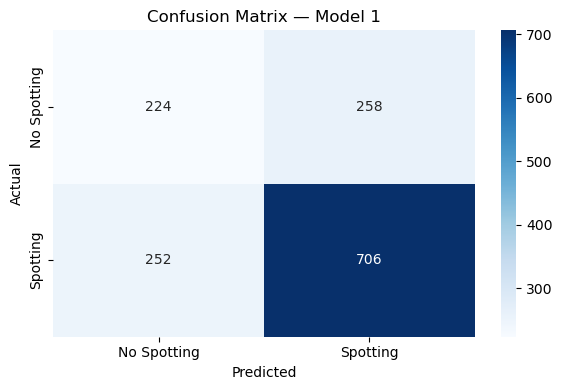

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, confusion_matrix,
                             classification_report)
import seaborn as sns
import matplotlib.pyplot as plt

# Train Model 1
clf = RandomForestClassifier(
    n_estimators=100,      # 100 decision trees
    max_depth=10,          # each tree can go 10 levels deep
    class_weight='balanced', # handle imbalance
    random_state=42
)
clf.fit(X_train_clf, y_train_clf)
print("Model 1 training complete.")

# Predictions
y_pred_clf = clf.predict(X_test_clf)

# Evaluation metrics
print("\nModel 1 — Classification Report:")
print(classification_report(y_test_clf, y_pred_clf, 
      target_names=['No Spotting', 'Spotting']))

# Confusion matrix
cm = confusion_matrix(y_test_clf, y_pred_clf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Spotting', 'Spotting'],
            yticklabels=['No Spotting', 'Spotting'])
plt.title('Confusion Matrix — Model 1')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Model 2 training complete.

Model 2 — Regression Results:
  MAE  (Mean Absolute Error): 0.577
  RMSE (Root Mean Sq Error):  0.736
  R²   (Explained Variance):  0.609


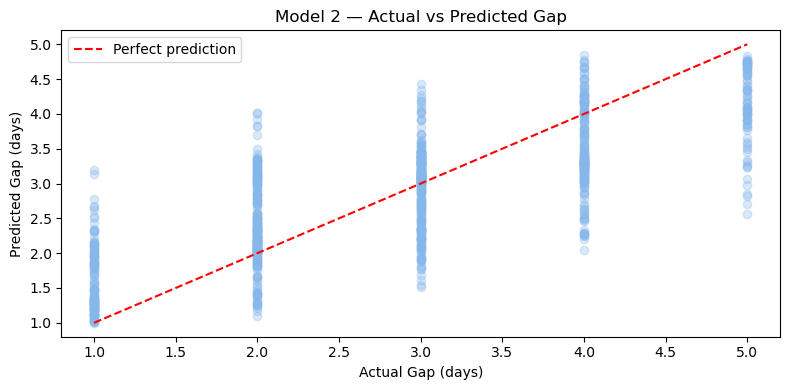

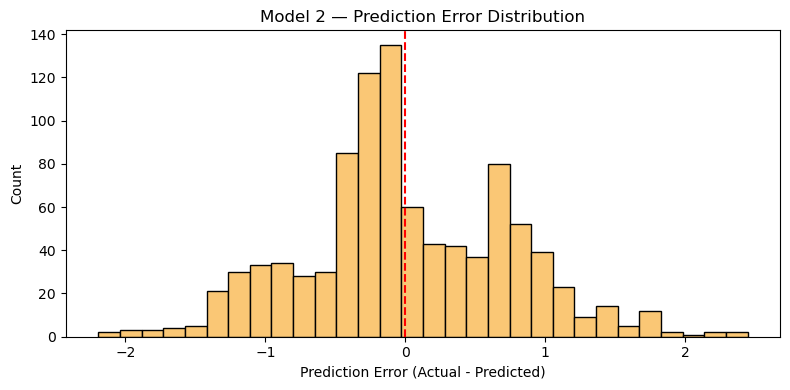

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train Model 2
reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
reg.fit(X_train_reg, y_train_reg)
print("Model 2 training complete.")

# Predictions
y_pred_reg = reg.predict(X_test_reg)

# Evaluation metrics
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"\nModel 2 — Regression Results:")
print(f"  MAE  (Mean Absolute Error): {round(mae, 3)}")
print(f"  RMSE (Root Mean Sq Error):  {round(rmse, 3)}")
print(f"  R²   (Explained Variance):  {round(r2, 3)}")

# Visualise actual vs predicted
plt.figure(figsize=(8, 4))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.3, color='#85B7EB')
plt.plot([1, 5], [1, 5], color='red', linestyle='--', label='Perfect prediction')
plt.xlabel('Actual Gap (days)')
plt.ylabel('Predicted Gap (days)')
plt.title('Model 2 — Actual vs Predicted Gap')
plt.legend()
plt.tight_layout()
plt.show()

# Distribution of prediction errors
errors = y_test_reg.values - y_pred_reg
plt.figure(figsize=(8, 4))
plt.hist(errors, bins=30, color='#FAC775', edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Count')
plt.title('Model 2 — Prediction Error Distribution')
plt.tight_layout()
plt.show()

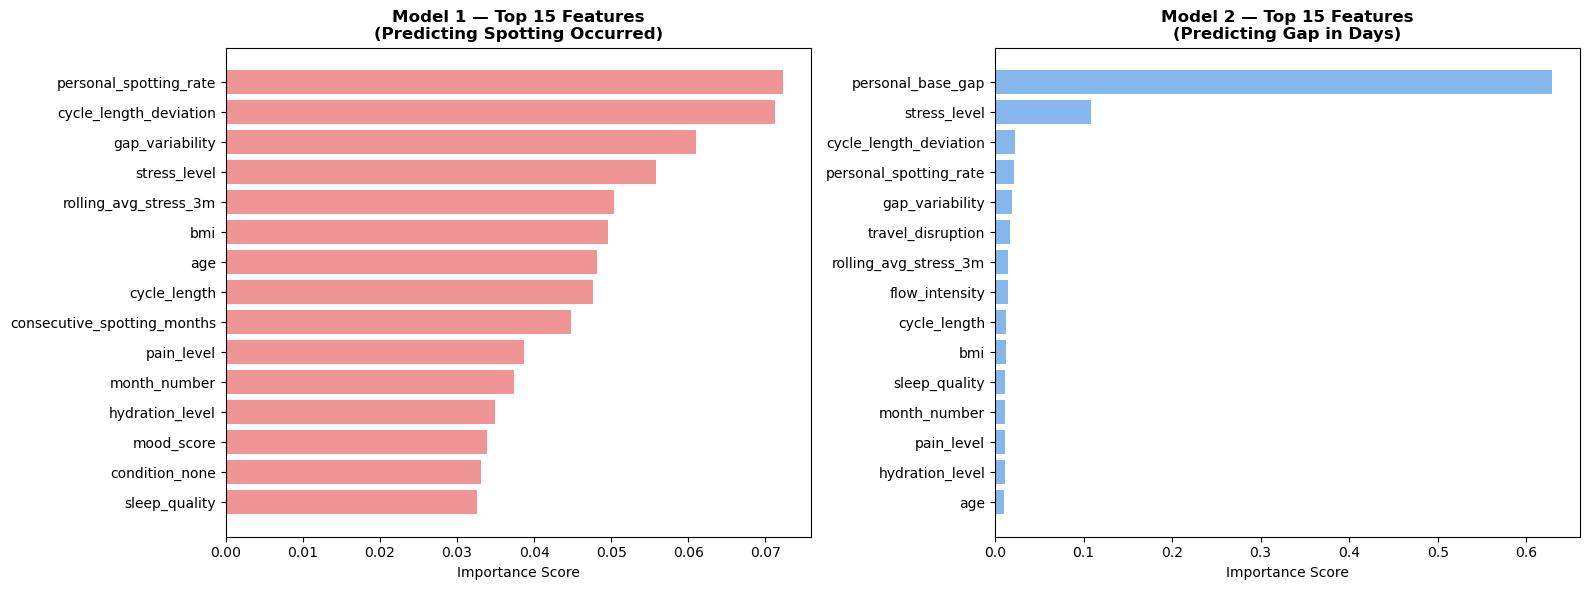

Model 1 — Top 10 Features:
   1. personal_spotting_rate              0.0723
   2. cycle_length_deviation              0.0713
   3. gap_variability                     0.061
   4. stress_level                        0.0558
   5. rolling_avg_stress_3m               0.0503
   6. bmi                                 0.0496
   7. age                                 0.0482
   8. cycle_length                        0.0476
   9. consecutive_spotting_months         0.0448
  10. pain_level                          0.0387

Model 2 — Top 10 Features:
   1. personal_base_gap                   0.6292
   2. stress_level                        0.108
   3. cycle_length_deviation              0.0227
   4. personal_spotting_rate              0.0213
   5. gap_variability                     0.0193
   6. travel_disruption                   0.0168
   7. rolling_avg_stress_3m               0.0146
   8. flow_intensity                      0.0144
   9. cycle_length                        0.0125
  10. bmi       

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = X_train_clf.columns.tolist()

# Model 1 — Classification feature importance
clf_importance = pd.Series(clf.feature_importances_, index=feature_names)
clf_importance = clf_importance.sort_values(ascending=False).head(15)

# Model 2 — Regression feature importance
reg_importance = pd.Series(reg.feature_importances_, index=feature_names)
reg_importance = reg_importance.sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Model 1
axes[0].barh(clf_importance.index[::-1], clf_importance.values[::-1], color='#F09595')
axes[0].set_title('Model 1 — Top 15 Features\n(Predicting Spotting Occurred)', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# Plot Model 2
axes[1].barh(reg_importance.index[::-1], reg_importance.values[::-1], color='#85B7EB')
axes[1].set_title('Model 2 — Top 15 Features\n(Predicting Gap in Days)', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

# Print top 10 for each
print("Model 1 — Top 10 Features:")
for i, (feat, score) in enumerate(clf_importance.head(10).items(), 1):
    print(f"  {i:2}. {feat:35} {round(score, 4)}")

print("\nModel 2 — Top 10 Features:")
for i, (feat, score) in enumerate(reg_importance.head(10).items(), 1):
    print(f"  {i:2}. {feat:35} {round(score, 4)}")

In [17]:
import numpy as np
import pandas as pd

def predict_cycle(input_data: dict):
    """
    input_data: dictionary of all 37 features for current cycle
    Returns prediction and recommendation
    """
    # Convert input to dataframe
    input_df = pd.DataFrame([input_data])
    
    # Ensure column order matches training data
    input_df = input_df[X_train_clf.columns]
    
    # Step 1 — Predict spotting probability
    spotting_prob = clf.predict_proba(input_df)[0][1]
    spotting_pred = clf.predict(input_df)[0]
    
    # Step 2 — If spotting predicted, predict gap
    if spotting_pred == 1:
        gap_pred = reg.predict(input_df)[0]
        gap_days = round(gap_pred)
        # Always use minimum safe window
        safe_window = max(1, gap_days - 1)
        recommendation = (
            f"Spotting likely this cycle ({round(spotting_prob*100)}% probability). "
            f"Bleeding expected in {gap_days} days. "
            f"Carry a pad within {safe_window} day(s) of spotting to be safe."
        )
    else:
        gap_pred = None
        recommendation = (
            f"Spotting unlikely this cycle ({round(spotting_prob*100)}% probability). "
            f"Period may start directly without spotting."
        )
    
    return {
        'spotting_probability': round(spotting_prob, 3),
        'spotting_predicted': bool(spotting_pred),
        'gap_days_predicted': round(gap_pred) if gap_pred else None,
        'recommendation': recommendation
    }

# Test with a sample user
sample_input = dict(zip(X_train_clf.columns, X_test_clf.iloc[0].values))
result = predict_cycle(sample_input)

print("Sample Prediction:")
print(f"  Spotting Probability : {result['spotting_probability']}")
print(f"  Spotting Predicted   : {result['spotting_predicted']}")
print(f"  Gap Days Predicted   : {result['gap_days_predicted']}")
print(f"  Recommendation       : {result['recommendation']}")

Sample Prediction:
  Spotting Probability : 0.483
  Spotting Predicted   : False
  Gap Days Predicted   : None
  Recommendation       : Spotting unlikely this cycle (48% probability). Period may start directly without spotting.


In [18]:

import joblib

# Save models and scaler
joblib.dump(clf, 'model1_classifier.pkl')
joblib.dump(reg, 'model2_regressor.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Save feature column names — needed for input validation in backend
import json
with open('feature_columns.json', 'w') as f:
    json.dump(X_train_clf.columns.tolist(), f)

print("Models saved successfully.")
print("Files created:")
print("  - model1_classifier.pkl")
print("  - model2_regressor.pkl")
print("  - scaler.pkl")
print("  - feature_columns.json")

Models saved successfully.
Files created:
  - model1_classifier.pkl
  - model2_regressor.pkl
  - scaler.pkl
  - feature_columns.json
